## Diffusion-Ergodic 项目环境初始化 + 配置 + 设备 + 种子

In [ ]:
"""
Diffusion-Ergodic 项目环境初始化
自动设置Python路径并导入必要模块
"""

import sys
import os
from pathlib import Path

# 设置项目根目录
project_root = Path('/home/songxy/code/Diffusion-Ergodic')
sys.path.insert(0, str(project_root))

# 导入常用库
import torch
import numpy as np
import matplotlib.pyplot as plt
import yaml

print("✓ 环境初始化完成")
print(f"项目根目录: {project_root}")
print(f"使用设备: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
from pathlib import Path
import yaml, torch, random, numpy as np

CONFIG_PATH = "config/config_ergodic.yaml"  # Notebook 位于 diffusion_ergodic/ 下
with open(CONFIG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

# 可选debug覆盖,做小范围测试
USE_DEBUG = False
if USE_DEBUG:
    tr = cfg.setdefault("training", {})
    tr["debug"] = True
    tr["batch_size"] = min(int(tr.get("batch_size", 8)), 4)
    tr["max_epochs"] = min(int(tr.get("max_epochs", 10)), 1)

# 设备选择
tr = cfg.get("training", {})
device_str = tr.get("device", "cuda" if torch.cuda.is_available() else "cpu")
device = torch.device(device_str)

# 随机种子
seed = int(tr.get("seed", 42))
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print(f"Loaded config: {CONFIG_PATH}")
print(f"Device: {device} | Seed: {seed}")



## 数据加载 + 单个 batch 可视化

In [ ]:
# Data loading + one-batch visualization using project loader

import torch, numpy as np
import matplotlib.pyplot as plt

# 1) 读取官方配置（确保均值/方差为 torch.tensor，字段齐全）
from diffusion_ergodic.main import load_config
CONFIG_PATH = "config/config_ergodic.yaml"  # Notebook 在 diffusion_ergodic/ 下
config = load_config(CONFIG_PATH)

# 2) 构建 DataLoader
from diffusion_ergodic.data_process.ergodic_processor import get_data_loaders
train_loader, val_loader = get_data_loaders(config)

# 3) 取一个 batch 并打印结构
batch = next(iter(train_loader))
if isinstance(batch, dict):
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            print(f"{k}: {tuple(v.shape)} | {v.dtype} | device={v.device}")
else:
    if isinstance(batch, (list, tuple)) and len(batch) >= 1 and isinstance(batch[0], torch.Tensor):
        print("x:", tuple(batch[0].shape))
        if len(batch) > 1 and isinstance(batch[1], torch.Tensor):
            print("y:", tuple(batch[1].shape))

# 4) 可视化（与之前相同）
def visualize_batch(batch, vis_count=4, title="train_batch"):
    def to_np(x): return x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else x
    x = None
    if isinstance(batch, dict):
        for k in ["trajectories","trajectory","traj","x","data","samples"]:
            if k in batch and isinstance(batch[k], torch.Tensor):
                x = batch[k]; break
        if x is None:
            for v in batch.values():
                if isinstance(v, torch.Tensor):
                    x = v; break
    elif isinstance(batch, (list, tuple)):
        x = batch[0] if isinstance(batch[0], torch.Tensor) else None
    if x is None:
        print("未识别数据张量，跳过可视化"); return
    x = to_np(x)

    if x.ndim == 3 and x.shape[-1] in (2, 3):
        B, T, C = x.shape
        n = min(vis_count, B)
        fig, axes = plt.subplots(1, n, figsize=(4*n, 4)); axes = [axes] if n==1 else axes
        for i in range(n):
            xi = x[i]
            if C >= 2:
                axes[i].plot(xi[:,0], xi[:,1], '-o', ms=2, lw=1)
                axes[i].scatter(xi[:1,0], xi[:1,1], c='g', s=20, label='start')
                axes[i].scatter(xi[-1:,0], xi[-1:,1], c='r', s=20, label='end')
                axes[i].set_aspect('equal'); axes[i].grid(True, ls='--', alpha=0.3)
                axes[i].set_title(f"traj {i}")
        axes[0].legend(loc='best'); plt.suptitle(title); plt.show(); return

    if x.ndim == 3:
        B, H, W = x.shape
        n = min(vis_count, B)
        fig, axes = plt.subplots(1, n, figsize=(4*n, 4)); axes = [axes] if n==1 else axes
        for i in range(n):
            axes[i].imshow(x[i], cmap='viridis', origin='lower')
            axes[i].set_title(f"sample {i}"); axes[i].axis('off')
        plt.suptitle(title); plt.show(); return

    if x.ndim == 4 and x.shape[1] in (1, 3):
        B, C, H, W = x.shape
        n = min(vis_count, B)
        fig, axes = plt.subplots(1, n, figsize=(4*n, 4)); axes = [axes] if n==1 else axes
        for i in range(n):
            img = x[i].transpose(1,2,0)
            if C == 1: img = img[...,0]
            axes[i].imshow(img, cmap='viridis' if C==1 else None, origin='lower')
            ax.set_aspect('equal')
            axes[i].set_title(f"sample {i}"); axes[i].axis('off')
        plt.suptitle(title); plt.show(); return

    print("未识别的数据形状，已跳过可视化。")

visualize_batch(batch, vis_count=4, title="train_batch")


## SDE 与公共工具

In [ ]:
# SDE (VPSDE_linear) and utility helpers

import torch
import math

STD_MIN = 1e-6

class VPSDE_linear:
    def __init__(self, beta_min=0.1, beta_max=20.0):
        self._beta_min = beta_min
        self._beta_max = beta_max

    @property
    def T(self):
        return 1.0

    def sde(self, x, t):
        # drift = -0.5 * beta(t) * x,  diffusion = sqrt(beta(t))
        shape = x.shape
        t = t.view(-1, *([1] * (len(shape)-1)))
        beta_t = (self._beta_max - self._beta_min) * t + self._beta_min
        drift = -0.5 * beta_t * x
        diffusion = torch.sqrt(beta_t)
        return drift, diffusion

    def marginal_prob(self, x, t):
        # x_t = exp(mean_log_coeff) * x0 + std * z
        shape = x.shape
        t = t.view(-1, *([1] * (len(shape)-1)))
        mean_log_coeff = -0.25 * t**2 * (self._beta_max - self._beta_min) - 0.5 * self._beta_min * t
        mean = torch.exp(mean_log_coeff) * x
        std = torch.sqrt(torch.clamp(1 - torch.exp(2.*mean_log_coeff), min=STD_MIN))
        return mean, std

    def diffusion_coeff(self, t):
        beta_t = (self._beta_max - self._beta_min) * t + self._beta_min
        return torch.sqrt(beta_t)

    def marginal_prob_std(self, t):
        discount = torch.exp(-0.5 * t**2 * (self._beta_max - self._beta_min) - self._beta_min * t)
        std = torch.sqrt(torch.clamp(1 - discount, min=STD_MIN))
        return std

def get_hidden_dim(config, default=192):
    return int(getattr(config, 'hidden_dim',
               getattr(getattr(config, 'model', object()), 'hidden_dim', default)))

def get_traj_dims(config, default_T=101, default_D=4):
    T = int(getattr(config, 'trajectory_len',
             getattr(getattr(config, 'data', object()), 'trajectory_len', default_T)))
    D = int(getattr(config, 'robot_state_dim',
             getattr(getattr(config, 'data', object()), 'robot_state_dim', default_D)))
    return T, D

def get_dist_shape(config, default_hw=(32,32)):
    dd = getattr(config, 'distribution_dim',
         getattr(getattr(config, 'data', object()), 'distribution_dim', default_hw))
    H, W = int(dd[0]), int(dd[1])
    return H, W


## Encoder

In [ ]:
# ErgodicEncoder

import torch.nn as nn
import torch.nn.functional as F

class ErgodicEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.hidden_dim = get_hidden_dim(config)
        state_dim = int(getattr(config, 'robot_state_dim',
                        getattr(getattr(config, 'data', object()), 'robot_state_dim', 4)))
        H, W = get_dist_shape(config)

        self.robot_encoder = nn.Sequential(
            nn.Linear(state_dim, self.hidden_dim // 2),
            nn.GELU(),
            nn.Linear(self.hidden_dim // 2, self.hidden_dim)
        )

        self.distribution_encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1, stride=2),
            nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=2),
            nn.GELU()
        )
        dist_h, dist_w = H // 4, W // 4
        dist_feature_size = dist_h * dist_w * 64
        self.distribution_projector = nn.Sequential(
            nn.Flatten(),
            nn.Linear(dist_feature_size, self.hidden_dim),
            nn.GELU(),
            nn.Linear(self.hidden_dim, self.hidden_dim)
        )

        self.fusion = nn.Sequential(
            nn.LayerNorm(self.hidden_dim),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.GELU(),
            nn.LayerNorm(self.hidden_dim)
        )

    def forward(self, inputs):
        rs = inputs['robot_state']        # [B, state_dim] (标准化)
        dist = inputs['distribution']     # [B, 1, H, W]
        rs_enc = self.robot_encoder(rs)
        dist_feat = self.distribution_encoder(dist)
        dist_enc = self.distribution_projector(dist_feat)
        enc = self.fusion(rs_enc + dist_enc)
        return {"encoding": enc, "robot_state": rs}


## DiT/Decoder + 采样包装

In [ ]:
# DiT blocks + Decoder + DPM-Solver wrapper call

import torch
import torch.nn as nn
import torch.nn.functional as F
from timm.models.layers import Mlp

# 时间步嵌入
class TimestepEmbedder(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.half_dim = hidden_dim // 2
        self.emb = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, t):
        freqs = torch.exp(-math.log(10000) * torch.arange(
            start=0, end=self.half_dim, device=t.device) / self.half_dim)
        args = t[:, None] * freqs[None, :]
        emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        return self.emb(emb)

# 简化版 DiT Block
class DiTBlock(nn.Module):
    def __init__(self, hidden_dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.self_attn = nn.MultiheadAttention(hidden_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.cross_attn = nn.MultiheadAttention(hidden_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm3 = nn.LayerNorm(hidden_dim)
        self.mlp = Mlp(in_features=hidden_dim, hidden_features=int(hidden_dim*mlp_ratio),
                       act_layer=nn.GELU, drop=dropout)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, context=None):
        # self-attn
        h = self.norm1(x)
        h = h.unsqueeze(1)
        h = self.self_attn(h, h, h)[0].squeeze(1)
        x = x + self.drop(h)
        # cross-attn
        if context is not None:
            h = self.norm2(x)
            h = h.unsqueeze(1)
            c = context.unsqueeze(1)
            h = self.cross_attn(h, c, c)[0].squeeze(1)
            x = x + self.drop(h)
        # mlp
        h = self.norm3(x)
        h = self.mlp(h)
        x = x + self.drop(h)
        return x

# 最后一层
class FinalLayer(nn.Module):
    def __init__(self, hidden_dim, output_dim):
        super().__init__()
        self.norm = nn.LayerNorm(hidden_dim)
        self.proj = nn.Linear(hidden_dim, output_dim)
    def forward(self, x, t_emb):
        return self.proj(self.norm(x))

# 轨迹向量级 DiT
class ErgodicDiT(nn.Module):
    def __init__(self, output_dim, hidden_dim, depth, heads, dropout=0.1, model_type="x_start"):
        super().__init__()
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.model_type = model_type
        self.traj_proj = nn.Sequential(
            nn.Linear(output_dim, hidden_dim*2),
            nn.GELU(),
            nn.Linear(hidden_dim*2, hidden_dim)
        )
        self.t_embedder = TimestepEmbedder(hidden_dim)
        self.blocks = nn.ModuleList([DiTBlock(hidden_dim, heads, dropout=dropout) for _ in range(depth)])
        self.final = FinalLayer(hidden_dim, output_dim)

    def forward(self, x, t, context, conditions=None):
        # conditions: {0: rs_phys} 以时刻 0 为键的硬性钳位
        if conditions is not None and 0 in conditions and conditions[0] is not None:
            B = x.shape[0]
            # 推断每步维度
            # NOTE: 在 Decoder 中我们知道 T 和 D，故处理放在上层
        h = self.traj_proj(x)
        t_emb = self.t_embedder(t)
        h = h + t_emb
        for blk in self.blocks:
            h = blk(h, context)
        return self.final(h, t_emb)

# Decoder：负责把编码与时间步/轨迹向量结合
from models.diffusion_utils.sampling import dpm_sampler  # 复用现有求解器

class ErgodicDecoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.trajectory_len, self.robot_state_dim = get_traj_dims(config)
        self.output_dim = self.trajectory_len * self.robot_state_dim
        hd = get_hidden_dim(config)
        depth = int(getattr(config, 'decoder_depth',
                     getattr(getattr(config, 'model', object()), 'decoder_depth', 3)))
        heads = int(getattr(config, 'num_heads',
                     getattr(getattr(config, 'model', object()), 'num_heads', 6)))
        drop = float(getattr(config, 'decoder_drop_path_rate',
                       getattr(getattr(config, 'model', object()), 'decoder_drop_path_rate', 0.1)))
        self.model_type = str(getattr(config, 'diffusion_model_type',
                           getattr(getattr(config, 'diffusion', object()), 'model_type', "x_start")))
        self.dit = ErgodicDiT(self.output_dim, hd, depth, heads, dropout=drop, model_type=self.model_type)

    def forward(self, encoder_outputs, inputs):
        enc = encoder_outputs['encoding']                 # [B, hidden_dim]
        B = enc.shape[0]
        # 训练路径：期望 inputs 含 'trajectories' (x_t) 与 'diffusion_time'
        if 'trajectories' in inputs and 'diffusion_time' in inputs:
            traj = inputs['trajectories']                # [B, T, D]
            t = inputs['diffusion_time']                 # [B]
            T, D = self.trajectory_len, self.robot_state_dim
            x = traj.view(B, T*D)
            # 条件整合
            conds = inputs.get('conditions')
            if conds is not None and 0 in conds and conds[0] is not None:
                # 将时刻 0 的位置强制写回
                x_view = x.view(B, T, D)
                x_view[:, 0, :] = conds[0].to(x_view.device)
                x = x_view.view(B, T*D)
            out = self.dit(x, t, enc, conditions=None)   # 输出 [B, T*D]
            return {"score": out.view(B, T, D), "diffusion_time": t}
        return {}

    @torch.no_grad()
    def inference(self, encoder_outputs, inputs):
        enc = encoder_outputs['encoding']                # [B, hidden_dim]
        B = enc.shape[0]
        T, D = self.trajectory_len, self.robot_state_dim
        x_T = torch.randn(B, T*D, device=enc.device)
        other = {"context": enc}
        if isinstance(inputs, dict) and inputs.get('robot_state') is not None:
            other["conditions"] = {0: inputs['robot_state']}
        steps = int(getattr(self.config, 'diffusion_steps',
                     getattr(getattr(self.config, 'diffusion', object()), 'steps', 20)))
        x0 = dpm_sampler(model=self.dit, x_T=x_T, other_model_params=other, diffusion_steps=steps)
        traj = x0.view(B, T, D)
        if isinstance(inputs, dict) and inputs.get('robot_state') is not None:
            traj[:, 0, :] = inputs['robot_state']
        return {"trajectories": traj}


## Cell 06 — 顶层 ErgodicDiffusionModel（含去噪训练修复）

In [ ]:
# 06 ErgodicDiffusionModel (x_t -> x0 denoising training)

import torch
import torch.nn as nn
import torch.nn.functional as F

class ErgodicDiffusionModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        # SDE
        beta_min = float(getattr(getattr(config, 'diffusion', object()), 'beta_min', 0.1))
        beta_max = float(getattr(getattr(config, 'diffusion', object()), 'beta_max', 20.0))
        self.sde = VPSDE_linear(beta_min=beta_min, beta_max=beta_max)

        # 模型组件
        self.encoder = ErgodicEncoder(config)
        self.decoder = ErgodicDecoder(config)

        # 仅使用 x_start 形式
        self.model_type = "x_start"

        # 起点硬约束强度常数（用于后续可能扩展，当前解码器直接硬钳）
        self.start_point_coef = float(getattr(getattr(config, 'diffusion', object()), 'start_point_coef', 10.0))

        self.last_loss_components = {}

    def _denorm_robot_state(self, rs: torch.Tensor) -> torch.Tensor:
        if rs is None:
            return None
        mean = self.config.normalizer.robot_state.mean.to(rs.device).view(1, -1)
        std  = self.config.normalizer.robot_state.std.to(rs.device).view(1, -1)
        return rs * std + mean

    def forward(self, inputs, training=None):
        # 1) 编码（Encoder 期望标准化的 robot_state）
        enc_in = {'distribution': inputs['distribution']}
        if 'robot_state' in inputs:
            enc_in['robot_state'] = inputs['robot_state']
        enc_out = self.encoder(enc_in)

        # 2) 加噪：x0 -> x_t（仅当有 trajectories + diffusion_time）
        decoder_inputs = {}
        x0 = inputs.get('trajectories')
        t  = inputs.get('diffusion_time')
        if x0 is not None and t is not None:
            B, T, D = x0.shape
            x0_flat = x0.view(B, -1)
            mean, std = self.sde.marginal_prob(x0_flat, t)
            z = torch.randn_like(mean)
            xt = (mean + std * z).view(B, T, D)
            decoder_inputs['trajectories']   = xt
            decoder_inputs['diffusion_time'] = t

        # 3) 起点硬约束（物理坐标）
        conditions = {}
        if inputs.get('robot_state') is not None:
            conditions[0] = self._denorm_robot_state(inputs['robot_state'])
        if conditions:
            decoder_inputs['conditions'] = conditions

        # 4) 解码器：预测 x0
        out = self.decoder(enc_out, decoder_inputs)

        return {
            'prediction': out.get('score', out.get('prediction')),  # 预测的 x0 (B,T,D)
            'diffusion_time': t,
            'robot_state': inputs.get('robot_state')
        }

    def compute_loss(self, outputs, target_trajectories):
        pred = outputs['prediction']
        mse = F.mse_loss(pred, target_trajectories)
        self.last_loss_components = {'mse_loss': float(mse), 'total_loss': float(mse)}
        return mse

    @torch.no_grad()
    def inference(self, inputs):
        # Encoder 用标准化 rs；Decoder 条件用反标准化 rs
        enc_out = self.encoder(inputs)
        dec_in = {}
        if inputs.get('robot_state') is not None:
            dec_in['robot_state'] = self._denorm_robot_state(inputs['robot_state'])
        out = self.decoder.inference(enc_out, dec_in)
        return {'prediction': out.get('trajectories', out.get('prediction'))}

    def get_loss_components(self):
        return self.last_loss_components.copy()


### Cell 06.1 Patch masked loss

In [ ]:
# 06.1 Patch: masked MSE loss (ignore zero-padded timesteps)

import torch, numpy as np
from types import MethodType

def masked_mse_loss(pred, target, eps=1e-8):
    # pred/target: [B, T, D]
    mask = (target.abs().sum(dim=-1) > eps).float()      # [B, T]
    diff2 = ((pred - target)**2).sum(dim=-1)             # [B, T]
    num_dims = pred.shape[-1]
    loss = (diff2 * mask).sum() / (mask.sum() * num_dims + eps)
    return loss

def compute_loss_patched(self, outputs, target_trajectories):
    loss = masked_mse_loss(outputs['prediction'], target_trajectories)
    self.last_loss_components = {'mse_loss': float(loss), 'total_loss': float(loss)}
    return loss

# 1) 打补丁到类（影响随后新建的实例）
ErgodicDiffusionModel.compute_loss = compute_loss_patched

# 2) 若已存在 model，则重新绑定实例方法（可选、保险）
try:
    model.compute_loss = MethodType(compute_loss_patched, model)  # noqa: F821
    print("compute_loss patched on existing model instance.")
except NameError:
    print("compute_loss patched on class; build model after this cell.")


### 06.2 加权 masked MSE（强化后段）+ 轻微平滑正则

In [ ]:
# 06.3 Patch: time-weighted masked MSE + endpoint anchor + tiny smoothness

import torch, numpy as np
from types import MethodType

def last_valid_idx_mask(xy, eps=1e-8):
    # xy: [B,T,2]
    valid = (xy.abs().sum(dim=-1) > eps)  # [B,T]
    idx = valid.float().argmax(dim=1)     # 错误：这是第一个有效；我们要最后一个
    # 正确：用反转 trick 求 last valid
    rev = torch.flip(valid, dims=[1])     # 从尾部看第一个 true
    last_from_end = rev.float().argmax(dim=1)
    last = (valid.size(1)-1) - last_from_end
    return last, valid.float()

def masked_time_weighted_mse(pred, target, gamma=3.0, eps=1e-8):
    B,T,D = target.shape
    mask = (target.abs().sum(dim=-1) > eps).float()                # [B,T]
    t = torch.arange(T, device=target.device).float().view(1,T)
    w = (t / max(T-1,1))**gamma
    w = (w * mask).float()
    w = w / (w.sum(dim=1, keepdim=True) + eps)
    diff2 = ((pred - target)**2).sum(dim=-1)                       # [B,T]
    return ((diff2 * w).sum(dim=1).mean()) / D, mask

def endpoint_anchor(pred, target, mask, eps=1e-8):
    # 取每个样本的“最后有效步”做端点锚定
    B,T,D = target.shape
    last, _ = last_valid_idx_mask(target[...,:2], eps=eps)
    idx = last.view(B,1,1).expand(-1,1,D)                          # [B,1,D]
    p_end = pred.gather(dim=1, index=idx).squeeze(1)               # [B,D]
    t_end = target.gather(dim=1, index=idx).squeeze(1)             # [B,D]
    return torch.mean((p_end - t_end)**2)

def velocity_smoothness(pred, mask, eps=1e-8):
    v = pred[:,1:,:] - pred[:,:-1,:]                               # [B,T-1,D]
    m = (mask[:,1:]*mask[:,:-1]).unsqueeze(-1)                     # [B,T-1,1]
    return ((v**2)*m).sum() / (m.sum()*pred.shape[-1] + eps)

def compute_loss_stronger_tail(self, outputs, target_trajectories,
                               gamma=3.0, lambda_end=0.1, lambda_smooth=0.005):
    pred = outputs['prediction']
    main, mask = masked_time_weighted_mse(pred, target_trajectories, gamma=gamma)
    end  = endpoint_anchor(pred, target_trajectories, mask)
    smooth = velocity_smoothness(pred, mask)
    loss = main + lambda_end*end + lambda_smooth*smooth
    self.last_loss_components = {
        'mse_time_weighted': float(main),
        'endpoint_anchor': float(lambda_end*end),
        'smooth_reg': float(lambda_smooth*smooth),
        'total_loss': float(loss),
    }
    return loss

ErgodicDiffusionModel.compute_loss = compute_loss_stronger_tail
try:
    model.compute_loss = MethodType(compute_loss_stronger_tail, model)  # 若已建好 model
    print("compute_loss patched: time-weighted + endpoint anchor + smoothness.")
except NameError:
    print("compute_loss patched on class; build model after this cell.")


## Cell 07 — 构建模型 + 冒烟一步（前向/损失/反传）
模型冒烟 + 单步反传目的与意义
验证模型能否在真实数据上完成一次前向、损失计算与反向传播（最小训练步），确保数据契约与模型接口对齐，为正式训练铺路。
若此步正常，说明“配置→数据→模型→loss”链路通畅；若异常，能快速定位到模型或数据字段/维度问题。
输出期望

打印预测张量形状（应为 [B, T, 4]）、一次 loss 数值，以及各 loss 组件字典。
正常情况 loss 为正数且反向传播无异常；首次迭代 loss 大小仅用于冒烟，不代表训练收敛水平。

In [ ]:
# Model smoke test: forward + loss + one optimizer step

import torch
from diffusion_ergodic.models.diffusion_ergodic import ErgodicDiffusionModel

# 1) Device
device = torch.device(config.training.device if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 2) Build model
model = ErgodicDiffusionModel(config).to(device)
model.train()

# 3) Take a fresh batch
batch = next(iter(train_loader))

# Move needed tensors to device
inputs = {
    "distribution": batch["distribution"].to(device),   # [B, 1, 32, 32]
    "robot_state": batch["robot_state"].to(device),     # [B, 4]
    "trajectories": batch["trajectories"].to(device),   # [B, T, 4]
    "diffusion_time": torch.rand(batch["trajectories"].shape[0], device=device)  # [B], U(0,1)
}
target = batch["trajectories"].to(device)               # 训练目标

# 4) Forward + loss
with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type=="cuda")):
    outputs = model(inputs, training=True)
    loss = model.compute_loss(outputs, target)

print("Prediction shape:", tuple(outputs["prediction"].shape))
print("Loss:", float(loss))
print("Loss components:", model.get_loss_components())

# 5) One optimizer step (optional but useful)
opt = torch.optim.AdamW(model.parameters(),
                        lr=getattr(config.training, "learning_rate", 1e-3),
                        weight_decay=getattr(config.training, "weight_decay", 0.0))
opt.zero_grad(set_to_none=True)
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
opt.step()

print("One optimization step completed.")


In [ ]:
# 07 Build model + one-step smoke test

model = ErgodicDiffusionModel(config).to(device)
opt = torch.optim.AdamW(
    model.parameters(),
    lr=getattr(config.training, "learning_rate", 1e-3),
    weight_decay=getattr(config.training, "weight_decay", 0.0),
)

batch = next(iter(train_loader))
X = {
    "distribution": batch["distribution"].to(device),
    "robot_state":  batch["robot_state"].to(device),
    "trajectories": batch["trajectories"].to(device),
    "diffusion_time": torch.rand(batch["trajectories"].shape[0], device=device),
}
model.train()
opt.zero_grad(set_to_none=True)
out = model(X, training=True)
loss = model.compute_loss(out, X["trajectories"])
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
opt.step()

print("Prediction:", tuple(out["prediction"].shape), "Loss:", float(loss))


In [122]:
# Fix-Forward: do NOT enforce start condition during training; keep it only for inference

from types import MethodType
import torch

def forward_no_train_condition(self, inputs, training=None):
    # 1) encoder（需要标准化 rs）
    enc_in = {'distribution': inputs['distribution']}
    if 'robot_state' in inputs:
        enc_in['robot_state'] = inputs['robot_state']
    enc_out = self.encoder(enc_in)

    # 2) 训练路径：x0 -> xt（不施加起点硬约束）
    decoder_inputs = {}
    x0 = inputs.get('trajectories')
    t  = inputs.get('diffusion_time')
    if x0 is not None and t is not None:
        B, T, D = x0.shape
        x0_flat = x0.view(B, -1)
        mean, std = self.sde.marginal_prob(x0_flat, t)
        z = torch.randn_like(mean)
        xt = (mean + std * z).view(B, T, D)
        decoder_inputs['trajectories']   = xt
        decoder_inputs['diffusion_time'] = t
        # 训练时不加 conditions

    # 3) 推理路径：仅采样时施加起点（物理坐标）
    if x0 is None and inputs.get('robot_state') is not None:
        decoder_inputs['conditions'] = {0: self._denorm_robot_state(inputs['robot_state'])}

    # 4) 解码器：预测 x0
    out = self.decoder(enc_out, decoder_inputs)
    return {
        'prediction': out.get('score', out.get('prediction')),
        'diffusion_time': t,
        'robot_state': inputs.get('robot_state')
    }

# 绑定当前 model
model.forward = MethodType(forward_no_train_condition, model)
print("Patched model.forward: training path uses xt without start condition; inference keeps start.")


Patched model.forward: training path uses xt without start condition; inference keeps start.


## Cell 08 — 最小训练循环（短暖身）

In [ ]:
# 08 Minimal warm-up training loop

import time, torch
model.train()
steps = 300
log_every = 30
running = 0.0
it = iter(train_loader)

for s in range(steps):
    try:
        batch = next(it)
    except StopIteration:
        it = iter(train_loader); batch = next(it)

    X = {
        "distribution": batch["distribution"].to(device),
        "robot_state":  batch["robot_state"].to(device),
        "trajectories": batch["trajectories"].to(device),
        "diffusion_time": torch.rand(batch["trajectories"].shape[0], device=device),
    }
    opt.zero_grad(set_to_none=True)
    out = model(X, training=True)
    loss = model.compute_loss(out, X["trajectories"])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()

    running += float(loss)
    if (s+1) % log_every == 0:
        print(f"step {s+1}/{steps}  loss={running/log_every:.4f}")
        running = 0.0

# quick val on few batches
@torch.no_grad()
def quick_val(dataloader, max_batches=10):
    model.eval()
    tot, n = 0.0, 0
    it = iter(dataloader)
    for _ in range(max_batches):
        try:
            b = next(it)
        except StopIteration:
            break
        X = {
            "distribution": b["distribution"].to(device),
            "robot_state":  b["robot_state"].to(device),
            "trajectories": b["trajectories"].to(device),
            "diffusion_time": torch.rand(b["trajectories"].shape[0], device=device),
        }
        out = model(X, training=True)
        l = model.compute_loss(out, X["trajectories"])
        tot += float(l); n += 1
    return tot/max(1,n)

val_est = quick_val(val_loader, max_batches=10)
print(f"quick val loss ≈ {val_est:.4f}")


## Cell B — 短微调循环（巩固端点对齐，降低分散）

In [ ]:
# 08c Short fine-tune focusing tail

import torch
model.train()
steps = 1500
log_every = 50
running = 0.0
it = iter(train_loader)

# 采样步数仅影响推理；训练仍是加噪前向
if hasattr(config, "diffusion"):
    config.diffusion.steps = 60

for s in range(steps):
    try:
        batch = next(it)
    except StopIteration:
        it = iter(train_loader); batch = next(it)
    X = {
        "distribution": batch["distribution"].to(device),
        "robot_state":  batch["robot_state"].to(device),
        "trajectories": batch["trajectories"].to(device),
        "diffusion_time": torch.rand(batch["trajectories"].shape[0], device=device),
    }
    opt.zero_grad(set_to_none=True)
    out = model(X, training=True)
    loss = model.compute_loss(out, X["trajectories"])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()

    running += float(loss)
    if (s+1) % log_every == 0:
        print(f"step {s+1}/{steps}  loss={running/log_every:.4f}")
        running = 0.0


## Cell 09 — 端点分布/尾步跳变复检（与数据端点对比）

In [ ]:
# 09 Aligned diagnostics: last-valid step for GT/pred; single-pass consistency

import numpy as np, torch, matplotlib.pyplot as plt

def to_np(x): 
    return x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)

def last_valid_idx_xy(traj_xy, eps=1e-12):
    valid = ~(np.all(np.abs(traj_xy) <= eps, axis=1))
    return (np.nonzero(valid)[0][-1]) if valid.any() else traj_xy.shape[0]-1

@torch.no_grad()
def collect_pred_gt(N=1024):
    model.eval()
    pred_pts, gt_pts, start_pts = [], [], []
    cnt = 0
    for b in val_loader:
        dist = b["distribution"].to(device)
        rs   = b["robot_state"].to(device)
        gt   = b["trajectories"]                         # [B,T,4] 物理坐标（含padding）
        out  = model.inference({"distribution": dist, "robot_state": rs})
        pred = out["prediction"]                         # [B,T,4]

        # 起点反标准化
        mean = model.config.normalizer.robot_state.mean.cpu().view(1,-1).numpy()
        std  = model.config.normalizer.robot_state.std.cpu().view(1,-1).numpy()
        rs_phys = (rs.cpu().numpy() * std + mean)       # [B,D]

        for i in range(pred.shape[0]):
            gt_xy = gt[i, :, :2].cpu().numpy()
            k = last_valid_idx_xy(gt_xy)
            pred_pts.append(pred[i, k, :2].cpu().numpy())
            gt_pts.append(gt_xy[k])
            start_pts.append(rs_phys[i, :2])
            cnt += 1
            if cnt >= N: break
        if cnt >= N: break
    return np.array(pred_pts), np.array(gt_pts), np.array(start_pts)

pred_pts, gt_pts, start_pts = collect_pred_gt(N=1024)

# 数值对比
se = np.linalg.norm(pred_pts - gt_pts, axis=1)
ss = np.linalg.norm(pred_pts - start_pts, axis=1)
print(f"Pred endpoints (aligned) mean={pred_pts.mean(0)} std={pred_pts.std(0, ddof=1)}")
print(f"GT   endpoints (aligned) mean={gt_pts.mean(0)} std={gt_pts.std(0, ddof=1)}")
print(f"mean ||pred_end - gt_end|| = {se.mean():.4f}")
print(f"mean ||pred_end - start||  = {ss.mean():.4f}")

# 散点
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.scatter(gt_pts[:,0], gt_pts[:,1], s=6, alpha=0.35); plt.title("GT endpoints (aligned)"); plt.gca().set_aspect('equal'); plt.grid(alpha=0.3)
plt.subplot(1,2,2); plt.scatter(pred_pts[:,0], pred_pts[:,1], s=6, alpha=0.35); plt.title("Pred endpoints (aligned)"); plt.gca().set_aspect('equal'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
# Endpoint bias + tail-jump statistics (aligned index)

import numpy as np, torch

def to_np(x): return x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)

def last_valid_idx_xy(xy, eps=1e-12):
    v = ~(np.all(np.abs(xy) <= eps, axis=1))
    return (np.nonzero(v)[0][-1]) if v.any() else xy.shape[0]-1

@torch.no_grad()
def collect(N=2048):
    model.eval()
    pred_pts, gt_pts = [], []
    ratios = []
    cnt = 0
    for b in val_loader:
        dist, rs = b["distribution"].to(device), b["robot_state"].to(device)
        gt = b["trajectories"]
        pred = model.inference({"distribution": dist, "robot_state": rs})["prediction"].cpu().numpy()
        gt = gt.cpu().numpy()
        for i in range(pred.shape[0]):
            k = last_valid_idx_xy(gt[i,:,:2])
            pred_pts.append(pred[i,k,:2]); gt_pts.append(gt[i,k,:2])
            # tail-jump at aligned k
            if k >= 2:
                steps = np.linalg.norm(pred[i,1:k+1,:2]-pred[i,0:k,:2], axis=-1)
                if len(steps) >= 2:
                    ratios.append(steps[-1]/(np.median(steps[:-1])+1e-8))
            cnt += 1
            if cnt >= N: break
        if cnt >= N: break
    return np.array(pred_pts), np.array(gt_pts), np.array(ratios)

pred_pts, gt_pts, ratios = collect()

delta = pred_pts - gt_pts
rmse = np.sqrt((delta**2).sum(1)).mean()
mu = delta.mean(0); std_pred = pred_pts.std(0, ddof=1); std_gt = gt_pts.std(0, ddof=1)

print(f"endpoint bias muΔ={mu} | RMSE={rmse:.4f}")
print(f"std(pred)={std_pred} vs std(gt)={std_gt}")
if len(ratios):
    print(f"tail-jump ratio median/p90/p99 = {np.percentile(ratios,[50,90,99])}")


In [ ]:
# Enforce start condition inside DiT.forward during sampling

from types import MethodType

def dit_forward_patched(self, x, t, context, conditions=None):
    # x: [B, T*D]
    if conditions is not None and isinstance(conditions, dict) and 0 in conditions and conditions[0] is not None:
        B = x.shape[0]
        D = conditions[0].shape[-1]
        T = self.output_dim // D
        xv = x.view(B, T, D)
        xv[:, 0, :] = conditions[0].to(xv.device)
        x = xv.view(B, self.output_dim)
    # 原逻辑
    h = self.traj_proj(x)
    t_emb = self.t_embedder(t)
    h = h + t_emb
    for blk in self.blocks:
        h = blk(h, context)
    return self.final(h, t_emb)

# 绑定到当前模型实例（仅采样流程使用）
model.decoder.dit.forward = MethodType(dit_forward_patched, model.decoder.dit)
print("Patched DiT.forward to enforce start condition during sampling.")


## Cell 10：统一设置损失权重与采样步数（重绑 compute_loss）

In [ ]:
# 10. Set loss weights + sampler steps (bind to class and current model)

from types import MethodType

GAMMA = 4.0          # time weight for late timesteps
LAMBDA_END = 0.20    # endpoint anchor weight
LAMBDA_SMOOTH = 0.005
SAMPLER_STEPS = 60   # inference-time diffusion steps

def last_valid_idx_mask(xy, eps=1e-8):
    valid = (xy.abs().sum(dim=-1) > eps)            # [B,T]
    rev = torch.flip(valid, dims=[1])
    last_from_end = rev.float().argmax(dim=1)
    last = (valid.size(1)-1) - last_from_end
    return last, valid.float()

def masked_time_weighted_mse(pred, target, gamma=3.0, eps=1e-8):
    B,T,D = target.shape
    mask = (target.abs().sum(dim=-1) > eps).float()
    t = torch.arange(T, device=target.device).float().view(1,T)
    w = (t / max(T-1,1))**gamma
    w = (w * mask).float()
    w = w / (w.sum(dim=1, keepdim=True) + eps)
    diff2 = ((pred - target)**2).sum(dim=-1)
    return ((diff2 * w).sum(dim=1).mean()) / D, mask

def endpoint_anchor(pred, target, mask, eps=1e-8):
    B,T,D = target.shape
    last, _ = last_valid_idx_mask(target[...,:2], eps=eps)
    idx = last.view(B,1,1).expand(-1,1,D)
    p_end = pred.gather(dim=1, index=idx).squeeze(1)
    t_end = target.gather(dim=1, index=idx).squeeze(1)
    return torch.mean((p_end - t_end)**2)

def velocity_smoothness(pred, mask, eps=1e-8):
    v = pred[:,1:,:] - pred[:,:-1,:]
    m = (mask[:,1:]*mask[:,:-1]).unsqueeze(-1)
    return ((v**2)*m).sum() / (m.sum()*pred.shape[-1] + eps)

def compute_loss_stronger_tail(self, outputs, target_trajectories,
                               gamma=GAMMA, lambda_end=LAMBDA_END, lambda_smooth=LAMBDA_SMOOTH):
    pred = outputs['prediction']
    main, mask = masked_time_weighted_mse(pred, target_trajectories, gamma=gamma)
    end  = endpoint_anchor(pred, target_trajectories, mask)
    smooth = velocity_smoothness(pred, mask)
    loss = main + lambda_end*end + lambda_smooth*smooth
    self.last_loss_components = {
        'mse_time_weighted': float(main),
        'endpoint_anchor': float(lambda_end*end),
        'smooth_reg': float(lambda_smooth*smooth),
        'total_loss': float(loss),
    }
    return loss

# bind to class and current model
ErgodicDiffusionModel.compute_loss = compute_loss_stronger_tail
try:
    model.compute_loss = MethodType(compute_loss_stronger_tail, model)
    print("compute_loss bound to current model with new weights.")
except NameError:
    print("compute_loss patched on class; build model if not present.")

# inference sampler steps
if hasattr(config, "diffusion"):
    config.diffusion.steps = SAMPLER_STEPS
print(f"inference diffusion_steps = {SAMPLER_STEPS}")


In [ ]:
# Robust patch for repo ErgodicDiT: supports 'dit_blocks'/'blocks' and 'output_layer'/'final'
from types import MethodType
import torch

def dit_forward_patched(self, x, t, context, conditions=None):
    # optional start condition at t=0
    if isinstance(conditions, dict) and 0 in conditions and conditions[0] is not None:
        B = x.shape[0]
        D = conditions[0].shape[-1]
        T = self.output_dim // D
        xv = x.view(B, T, D)
        xv[:, 0, :] = conditions[0].to(xv.device)
        x = xv.view(B, self.output_dim)

    # original forward body
    h = self.traj_proj(x)
    t_emb = self.t_embedder(t)
    h = h + t_emb

    # blocks: support both names
    blocks = getattr(self, "dit_blocks", None)
    if blocks is None:
        blocks = getattr(self, "blocks", None)
    if blocks is None:
        raise AttributeError("ErgodicDiT has neither 'dit_blocks' nor 'blocks'")

    for blk in blocks:
        h = blk(h, context)

    # output layer: support both names
    out_layer = getattr(self, "output_layer", None)
    if out_layer is None:
        out_layer = getattr(self, "final", None)
    if out_layer is None:
        raise AttributeError("ErgodicDiT has neither 'output_layer' nor 'final'")

    return out_layer(h, t_emb)

# bind to the current model instance (repo class)
model.decoder.dit.forward = MethodType(dit_forward_patched, model.decoder.dit)
print("Re-patched DiT.forward (compat with repo attribute names).")


### Cell 10b — 更强损失（末段窗口 + 尾步惩罚），并绑定到当前 model

In [ ]:
# 10b. Stronger tail loss: last-K window + tail jump penalty

from types import MethodType
import torch, numpy as np

GAMMA = 4.0           # 强调末段权重
LAMBDA_END  = 0.35    # 单点终点锚定
LAMBDA_ENDK = 0.15    # 末段K步窗口锚定
LAMBDA_SMOOTH = 0.003 # 轻微速度平滑
LAMBDA_TAIL  = 0.002  # 尾步大跳惩罚
TAIL_COEFF   = 1.8    # 尾步阈值系数 (last > c * mean_prev)
K_LAST = 5            # 末段窗口大小
SAMPLER_STEPS = 80    # 推理步数

def last_valid_idx_mask(xy, eps=1e-8):
    valid = (xy.abs().sum(dim=-1) > eps)            # [B,T]
    rev = torch.flip(valid, dims=[1])
    last_from_end = rev.float().argmax(dim=1)
    last = (valid.size(1)-1) - last_from_end
    return last, valid.float()

def masked_time_weighted_mse(pred, target, gamma=3.0, eps=1e-8):
    B,T,D = target.shape
    mask = (target.abs().sum(dim=-1) > eps).float()
    t = torch.arange(T, device=target.device).float().view(1,T)
    w = (t / max(T-1,1))**gamma
    w = (w * mask).float()
    w = w / (w.sum(dim=1, keepdim=True) + eps)
    diff2 = ((pred - target)**2).sum(dim=-1)
    return ((diff2 * w).sum(dim=1).mean()) / D, mask

def endpoint_anchor(pred, target, eps=1e-8):
    B,T,D = target.shape
    last, _ = last_valid_idx_mask(target[...,:2], eps=eps)
    idx = last.view(B,1,1).expand(-1,1,D)
    p_end = pred.gather(dim=1, index=idx).squeeze(1)
    t_end = target.gather(dim=1, index=idx).squeeze(1)
    return torch.mean((p_end - t_end)**2)

def endpoint_window_anchor(pred, target, K=5, eps=1e-8):
    # 对末段 K 个有效时刻施加窗口 MSE
    B,T,D = target.shape
    last, valid = last_valid_idx_mask(target[...,:2], eps=eps)
    loss, count = 0.0, 0
    for b in range(B):
        kb = int(last[b].item())
        kb0 = max(0, kb-K+1)
        m = valid[b, kb0:kb+1] > 0.5
        if m.any():
            p = pred[b, kb0:kb+1][m]
            t = target[b, kb0:kb+1][m]
            loss = loss + torch.mean((p - t)**2)
            count += 1
    if count == 0: return torch.tensor(0.0, device=target.device)
    return loss / count

def velocity_smoothness(pred, mask, eps=1e-8):
    v = pred[:,1:,:] - pred[:,:-1,:]
    m = (mask[:,1:]*mask[:,:-1]).unsqueeze(-1)
    return ((v**2)*m).sum() / (m.sum()*pred.shape[-1] + eps)

def tail_jump_penalty(pred, mask, coeff=1.8, eps=1e-8):
    # 惩罚 last_step >> mean_prev_step
    B,T,D = pred.shape
    v = pred[:,1:,:2] - pred[:,:-1,:2]                    # 仅 XY
    m_pair = (mask[:,1:]*mask[:,:-1]) > 0.5               # 有效相邻
    pen = 0.0; n=0
    for b in range(B):
        vb = v[b][m_pair[b]]
        if vb.shape[0] < 2: continue
        step = torch.linalg.norm(vb, dim=-1)              # [L]
        last = step[-1]
        mean_prev = step[:-1].mean()
        excess = torch.relu(last - coeff * mean_prev)
        pen = pen + excess**2
        n += 1
    if n == 0: return torch.tensor(0.0, device=pred.device)
    return pen / n

def compute_loss_strong_tail(self, outputs, target_trajectories,
                             gamma=GAMMA, lambda_end=LAMBDA_END,
                             lambda_endk=LAMBDA_ENDK, lambda_smooth=LAMBDA_SMOOTH,
                             lambda_tail=LAMBDA_TAIL, tail_coeff=TAIL_COEFF):
    pred = outputs['prediction']
    main, mask = masked_time_weighted_mse(pred, target_trajectories, gamma=gamma)
    end  = endpoint_anchor(pred, target_trajectories)
    endk = endpoint_window_anchor(pred, target_trajectories, K=K_LAST)
    smooth = velocity_smoothness(pred, mask)
    tpen = tail_jump_penalty(pred, mask, coeff=tail_coeff)
    loss = main + lambda_end*end + lambda_endk*endk + lambda_smooth*smooth + lambda_tail*tpen
    self.last_loss_components = {
        'mse_time_weighted': float(main),
        'endpoint_anchor': float(lambda_end*end),
        'endpoint_window': float(lambda_endk*endk),
        'smooth_reg': float(lambda_smooth*smooth),
        'tail_penalty': float(lambda_tail*tpen),
        'total_loss': float(loss),
    }
    return loss

# 绑定 compute_loss
ErgodicDiffusionModel.compute_loss = compute_loss_strong_tail
try:
    model.compute_loss = MethodType(compute_loss_strong_tail, model)
    print("compute_loss bound (strong tail version).")
except NameError:
    print("compute_loss patched on class; build model if needed.")

# 评估时采样步数
if hasattr(config, "diffusion"):
    config.diffusion.steps = SAMPLER_STEPS
print(f"inference diffusion_steps = {SAMPLER_STEPS}")


### Cell 10c — 更强“末段收敛”损失（端点质心/方差对齐 + 更强尾步惩罚），并把采样步数调到 100

In [ ]:
# 10e. Minimal endpoint-forcing loss (only END and ENDK)

from types import MethodType
import torch

GAMMA = 4.0
K_LAST = 5
L_END  = 2.0   # 强：单点终点锚定
L_ENDK = 1.0   # 强：末段窗口锚定
SAMPLER_STEPS = 100

def last_valid_idx_mask(xy, eps=1e-8):
    valid = (xy.abs().sum(dim=-1) > eps)
    rev = torch.flip(valid, dims=[1])
    last_from_end = rev.float().argmax(dim=1)
    last = (valid.size(1)-1) - last_from_end
    return last, valid.float()

def masked_time_weighted_mse(pred, target, gamma=3.0, eps=1e-8):
    B,T,D = target.shape
    mask = (target.abs().sum(dim=-1) > eps).float()
    t = torch.arange(T, device=target.device).float().view(1,T)
    w = (t / max(T-1,1))**gamma
    w = (w * mask).float()
    w = w / (w.sum(dim=1, keepdim=True) + eps)
    diff2 = ((pred - target)**2).sum(dim=-1)
    return ((diff2 * w).sum(dim=1).mean()) / D, mask

def endpoint_anchor(pred, target, eps=1e-8):
    B,T,D = target.shape
    last,_= last_valid_idx_mask(target[...,:2], eps=eps)
    idx = last.view(B,1,1).expand(-1,1,D)
    p_end = pred.gather(dim=1, index=idx).squeeze(1)
    t_end = target.gather(dim=1, index=idx).squeeze(1)
    return torch.mean((p_end - t_end)**2)

def endpoint_window_anchor(pred, target, K=5, eps=1e-8):
    B,T,D = target.shape
    last, valid = last_valid_idx_mask(target[...,:2], eps=eps)
    loss, count = 0.0, 0
    for b in range(B):
        kb = int(last[b].item()); kb0 = max(0, kb-K+1)
        m = valid[b, kb0:kb+1] > 0.5
        if m.any():
            p = pred[b, kb0:kb+1][m]
            t = target[b, kb0:kb+1][m]
            loss += torch.mean((p - t)**2); count += 1
    if count == 0: return torch.tensor(0.0, device=pred.device)
    return loss / count

def compute_loss_minimal(self, outputs, target_trajectories,
                         gamma=GAMMA, lambda_end=L_END, lambda_endk=L_ENDK):
    pred = outputs['prediction']
    main, _ = masked_time_weighted_mse(pred, target_trajectories, gamma=gamma)
    end  = endpoint_anchor(pred, target_trajectories)
    endk = endpoint_window_anchor(pred, target_trajectories, K=K_LAST)
    loss = main + lambda_end*end + lambda_endk*endk
    self.last_loss_components = {
        'mse_time_weighted': float(main),
        'endpoint_anchor': float(lambda_end*end),
        'endpoint_window': float(lambda_endk*endk),
        'total_loss': float(loss),
    }
    return loss

ErgodicDiffusionModel.compute_loss = compute_loss_minimal
try:
    model.compute_loss = MethodType(compute_loss_minimal, model)
    print("compute_loss bound (minimal endpoint forcing).")
except NameError:
    print("compute_loss patched on class; build model if needed.")

if hasattr(config, "diffusion"):
    config.diffusion.steps = SAMPLER_STEPS
print(f"inference diffusion_steps = {SAMPLER_STEPS}")


## Cell 11：短微调循环（每 500 步评估一次对齐指标；达标则提前停止）

In [119]:
# 10e. Minimal endpoint-forcing loss (only END and ENDK)

from types import MethodType
import torch

GAMMA = 4.0
K_LAST = 5
L_END  = 2.0   # 强：单点终点锚定
L_ENDK = 1.0   # 强：末段窗口锚定
SAMPLER_STEPS = 100

def last_valid_idx_mask(xy, eps=1e-8):
    valid = (xy.abs().sum(dim=-1) > eps)
    rev = torch.flip(valid, dims=[1])
    last_from_end = rev.float().argmax(dim=1)
    last = (valid.size(1)-1) - last_from_end
    return last, valid.float()

def masked_time_weighted_mse(pred, target, gamma=3.0, eps=1e-8):
    B,T,D = target.shape
    mask = (target.abs().sum(dim=-1) > eps).float()
    t = torch.arange(T, device=target.device).float().view(1,T)
    w = (t / max(T-1,1))**gamma
    w = (w * mask).float()
    w = w / (w.sum(dim=1, keepdim=True) + eps)
    diff2 = ((pred - target)**2).sum(dim=-1)
    return ((diff2 * w).sum(dim=1).mean()) / D, mask

def endpoint_anchor(pred, target, eps=1e-8):
    B,T,D = target.shape
    last,_= last_valid_idx_mask(target[...,:2], eps=eps)
    idx = last.view(B,1,1).expand(-1,1,D)
    p_end = pred.gather(dim=1, index=idx).squeeze(1)
    t_end = target.gather(dim=1, index=idx).squeeze(1)
    return torch.mean((p_end - t_end)**2)

def endpoint_window_anchor(pred, target, K=5, eps=1e-8):
    B,T,D = target.shape
    last, valid = last_valid_idx_mask(target[...,:2], eps=eps)
    loss, count = 0.0, 0
    for b in range(B):
        kb = int(last[b].item()); kb0 = max(0, kb-K+1)
        m = valid[b, kb0:kb+1] > 0.5
        if m.any():
            p = pred[b, kb0:kb+1][m]
            t = target[b, kb0:kb+1][m]
            loss += torch.mean((p - t)**2); count += 1
    if count == 0: return torch.tensor(0.0, device=pred.device)
    return loss / count

def compute_loss_minimal(self, outputs, target_trajectories,
                         gamma=GAMMA, lambda_end=L_END, lambda_endk=L_ENDK):
    pred = outputs['prediction']
    main, _ = masked_time_weighted_mse(pred, target_trajectories, gamma=gamma)
    end  = endpoint_anchor(pred, target_trajectories)
    endk = endpoint_window_anchor(pred, target_trajectories, K=K_LAST)
    loss = main + lambda_end*end + lambda_endk*endk
    self.last_loss_components = {
        'mse_time_weighted': float(main),
        'endpoint_anchor': float(lambda_end*end),
        'endpoint_window': float(lambda_endk*endk),
        'total_loss': float(loss),
    }
    return loss

ErgodicDiffusionModel.compute_loss = compute_loss_minimal
try:
    model.compute_loss = MethodType(compute_loss_minimal, model)
    print("compute_loss bound (minimal endpoint forcing).")
except NameError:
    print("compute_loss patched on class; build model if needed.")

if hasattr(config, "diffusion"):
    config.diffusion.steps = SAMPLER_STEPS
print(f"inference diffusion_steps = {SAMPLER_STEPS}")


compute_loss bound (minimal endpoint forcing).
inference diffusion_steps = 100


### Cell 11b — 短微调 2000 步，500 步评估一次（中途减半学习率）

In [ ]:
# 11b. Fine-tune 2000 steps with LR drop + periodic aligned eval

import numpy as np, torch

# 可选：中途降学习率，细化收敛
for g in opt.param_groups:
    g['lr'] = g['lr'] * 0.7  # 小幅降到 0.7×，如仍振荡再降

def aligned_metrics(N=1024):
    model.eval()
    pred_pts, gt_pts, ratios = [], [], []
    cnt = 0
    with torch.no_grad():
        for b in val_loader:
            dist, rs = b["distribution"].to(device), b["robot_state"].to(device)
            gt = b["trajectories"].to(device)
            pred = model.inference({"distribution": dist, "robot_state": rs})["prediction"]
            for i in range(pred.shape[0]):
                gt_xy = gt[i,:,:2]
                valid = ~(gt_xy.abs().sum(dim=-1) <= 1e-8)
                k = torch.nonzero(valid)[-1].item() if valid.any() else gt_xy.shape[0]-1
                pred_pts.append(pred[i,k,:2].detach().cpu().numpy())
                gt_pts.append(gt[i,k,:2].detach().cpu().numpy())
                if k >= 2:
                    steps = torch.linalg.norm(pred[i,1:k+1,:2]-pred[i,0:k,:2], dim=-1).cpu().numpy()
                    if len(steps) >= 2:
                        ratios.append(steps[-1]/(np.median(steps[:-1])+1e-8))
                cnt += 1
                if cnt >= N: break
            if cnt >= N: break
    pred_pts, gt_pts = np.array(pred_pts), np.array(gt_pts)
    delta = pred_pts - gt_pts
    rmse = np.sqrt((delta**2).sum(1)).mean()
    mu = delta.mean(0); std_pred = pred_pts.std(0, ddof=1); std_gt = gt_pts.std(0, ddof=1)
    tail_p = np.percentile(ratios, [50,90,99]) if len(ratios) else [np.nan]*3
    return dict(mu=mu, rmse=rmse, std_pred=std_pred, std_gt=std_gt, tail=tail_p)

def meets_threshold(m):
    cond_bias = np.all(np.abs(m['mu']) < 0.02)
    cond_rmse = m['rmse'] < 0.05
    cond_std  = np.all(m['std_pred']/np.maximum(m['std_gt'],1e-8) < 2.0)
    cond_tail = (m['tail'][1] < 1.2) and (m['tail'][2] < 1.5)
    return cond_bias and cond_rmse and cond_std and cond_tail

total_steps = 2000
eval_every  = 500
running = 0.0
it = iter(train_loader)
model.train()

for s in range(1, total_steps+1):
    try:
        batch = next(it)
    except StopIteration:
        it = iter(train_loader); batch = next(it)

    X = {
        "distribution": batch["distribution"].to(device),
        "robot_state":  batch["robot_state"].to(device),
        "trajectories": batch["trajectories"].to(device),
        "diffusion_time": torch.rand(batch["trajectories"].shape[0], device=device),
    }
    opt.zero_grad(set_to_none=True)
    out = model(X, training=True)
    loss = model.compute_loss(out, X["trajectories"])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    running += float(loss)

    if s % 50 == 0:
        print(f"step {s}/{total_steps}  loss={running/50:.4f}")
        running = 0.0

    if s % eval_every == 0:
        m = aligned_metrics(N=1024)
        print(f"[eval @ {s}] mu={m['mu']}, rmse={m['rmse']:.4f}, "
              f"std(pred)={m['std_pred']}, std(gt)={m['std_gt']}, "
              f"tail(p50,p90,p99)={m['tail']}")
        if meets_threshold(m):
            print("Criteria met → 可以开启正式训练/长训。")
            break


### Cell 11c — 短微调 1000 步，250 步评估一次（满足阈值提前停）

In [123]:
# 11f. Short fine-tune 600 steps with only time-weighted masked MSE (no anchors)

import torch, numpy as np

# 仅时间加权 masked MSE
GAMMA = 4.0
def masked_time_weighted_mse(pred, target, gamma=3.0, eps=1e-8):
    B,T,D = target.shape
    mask = (target.abs().sum(dim=-1) > eps).float()
    t = torch.arange(T, device=target.device).float().view(1,T)
    w = (t / max(T-1,1))**gamma
    w = (w * mask).float()
    w = w / (w.sum(dim=1, keepdim=True) + eps)
    diff2 = ((pred - target)**2).sum(dim=-1)
    return ((diff2 * w).sum(dim=1).mean()) / D

from types import MethodType
def compute_loss_time_weighted(self, outputs, target_trajectories, gamma=GAMMA):
    pred = outputs['prediction']
    main = masked_time_weighted_mse(pred, target_trajectories, gamma=gamma)
    self.last_loss_components = {'mse_time_weighted': float(main), 'total_loss': float(main)}
    return main

ErgodicDiffusionModel.compute_loss = compute_loss_time_weighted
model.compute_loss = MethodType(compute_loss_time_weighted, model)
print("compute_loss bound to time-weighted masked MSE only.")

# 评估工具（对齐 last-valid）
def aligned_metrics(N=1024):
    model.eval()
    pred_pts, gt_pts, ratios = [], [], []
    cnt = 0
    with torch.no_grad():
        for b in val_loader:
            dist, rs = b["distribution"].to(device), b["robot_state"].to(device)
            gt = b["trajectories"].to(device)
            pred = model.inference({"distribution": dist, "robot_state": rs})["prediction"]
            for i in range(pred.shape[0]):
                gt_xy = gt[i,:,:2]
                valid = ~(gt_xy.abs().sum(dim=-1) <= 1e-8)
                k = torch.nonzero(valid)[-1].item() if valid.any() else gt_xy.shape[0]-1
                pred_pts.append(pred[i,k,:2].detach().cpu().numpy())
                gt_pts.append(gt[i,k,:2].detach().cpu().numpy())
                if k >= 2:
                    steps = torch.linalg.norm(pred[i,1:k+1,:2]-pred[i,0:k,:2], dim=-1).cpu().numpy()
                    if len(steps) >= 2:
                        ratios.append(steps[-1]/(np.median(steps[:-1])+1e-8))
                cnt += 1
                if cnt >= N: break
            if cnt >= N: break
    pred_pts, gt_pts = np.array(pred_pts), np.array(gt_pts)
    delta = pred_pts - gt_pts
    rmse = np.sqrt((delta**2).sum(1)).mean()
    mu = delta.mean(0); std_pred = pred_pts.std(0, ddof=1); std_gt = gt_pts.std(0, ddof=1)
    tail_p = np.percentile(ratios, [50,90,99]) if len(ratios) else [np.nan]*3
    return dict(mu=mu, rmse=rmse, std_pred=std_pred, std_gt=std_gt, tail=tail_p)

# 可选：采样步数略高
if hasattr(config, "diffusion"):
    config.diffusion.steps = 100

# 开始短微调
steps, eval_every = 600, 200
running, it = 0.0, iter(train_loader)
model.train()
for s in range(1, steps+1):
    try:
        batch = next(it)
    except StopIteration:
        it = iter(train_loader); batch = next(it)

    X = {
        "distribution": batch["distribution"].to(device),
        "robot_state":  batch["robot_state"].to(device),
        "trajectories": batch["trajectories"].to(device),
        "diffusion_time": torch.rand(batch["trajectories"].shape[0], device=device),
    }
    opt.zero_grad(set_to_none=True)
    out = model(X, training=True)
    loss = model.compute_loss(out, X["trajectories"])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    running += float(loss)

    if s % 50 == 0:
        comps = model.get_loss_components()
        print(f"step {s}/{steps}  loss={running/50:.4f}  comps={ {k: round(v,6) for k,v in comps.items()} }")
        running = 0.0

    if s % eval_every == 0:
        m = aligned_metrics(N=1024)
        print(f"[eval @ {s}] mu={m['mu']}, rmse={m['rmse']:.4f}, "
              f"std(pred)={m['std_pred']}, std(gt)={m['std_gt']}, "
              f"tail(p50,p90,p99)={m['tail']}")


compute_loss bound to time-weighted masked MSE only.
step 50/600  loss=0.0514  comps={'mse_time_weighted': 0.027128, 'total_loss': 0.027128}
step 100/600  loss=0.0294  comps={'mse_time_weighted': 0.031763, 'total_loss': 0.031763}
step 150/600  loss=0.0267  comps={'mse_time_weighted': 0.024183, 'total_loss': 0.024183}
step 200/600  loss=0.0254  comps={'mse_time_weighted': 0.023292, 'total_loss': 0.023292}
[eval @ 200] mu=[-0.00792285  0.00059021], rmse=0.0139, std(pred)=[0.00954498 0.00899317], std(gt)=[0.00597776 0.00715277], tail(p50,p90,p99)=[0.18265133 0.27967059 0.44444481]
step 250/600  loss=0.0220  comps={'mse_time_weighted': 0.021683, 'total_loss': 0.021683}
step 300/600  loss=0.0214  comps={'mse_time_weighted': 0.022831, 'total_loss': 0.022831}
step 350/600  loss=0.0208  comps={'mse_time_weighted': 0.019922, 'total_loss': 0.019922}
step 400/600  loss=0.0206  comps={'mse_time_weighted': 0.018532, 'total_loss': 0.018532}
[eval @ 400] mu=[-0.01193352 -0.00723372], rmse=0.0173, std

可选 Cell 12 — 再画一次散点

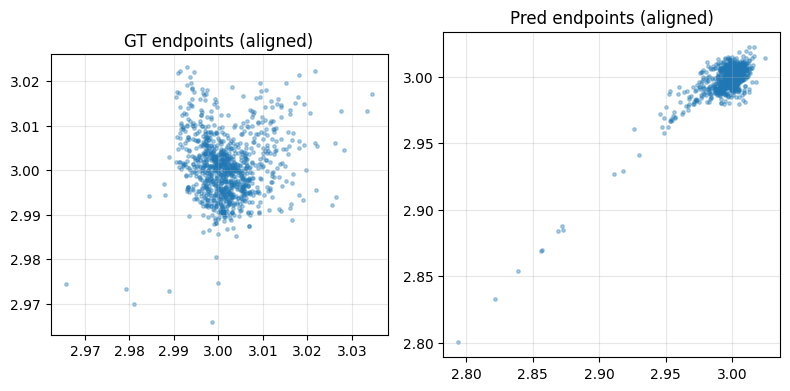

In [124]:
# 12. Plot aligned endpoints after fine-tune (optional)
import matplotlib.pyplot as plt, numpy as np, torch

@torch.no_grad()
def collect_pts(N=1024):
    model.eval()
    pred_pts, gt_pts = [], []
    cnt = 0
    for b in val_loader:
        dist, rs = b["distribution"].to(device), b["robot_state"].to(device)
        gt = b["trajectories"].to(device)
        pred = model.inference({"distribution": dist, "robot_state": rs})["prediction"]
        for i in range(pred.shape[0]):
            gt_xy = gt[i,:,:2]
            valid = ~(gt_xy.abs().sum(dim=-1) <= 1e-8)
            k = torch.nonzero(valid)[-1].item() if valid.any() else gt_xy.shape[0]-1
            pred_pts.append(pred[i,k,:2].detach().cpu().numpy())
            gt_pts.append(gt[i,k,:2].detach().cpu().numpy())
            cnt += 1
            if cnt >= N: break
        if cnt >= N: break
    return np.array(pred_pts), np.array(gt_pts)

pp, gg = collect_pts(N=1024)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.scatter(gg[:,0], gg[:,1], s=6, alpha=0.35); plt.title("GT endpoints (aligned)"); plt.gca().set_aspect('equal'); plt.grid(alpha=0.3)
plt.subplot(1,2,2); plt.scatter(pp[:,0], pp[:,1], s=6, alpha=0.35); plt.title("Pred endpoints (aligned)"); plt.gca().set_aspect('equal'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
